In [2]:
import os, torch, gc
import numpy as np
import pandas as pd
from torch.nn.functional import sigmoid
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import transforms
from sklearn.model_selection import train_test_split

from src.Models import (
    CancerClassifierResNet18_V1,
    CancerClassifierResNet50_V1,
    CancerClassifierCoaTLiteTiny,
    model_b0,
    HistopathologyDataset
)
import random
from torchvision.transforms.functional import to_pil_image

import torch
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
from torchcam.methods import SmoothGradCAMpp
import random
import numpy as np
from PIL import Image
from torch.serialization import safe_globals

from glob import glob

from tqdm import tqdm

import torch
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
from torchcam.methods import SmoothGradCAMpp
import random
import numpy as np
from PIL import Image
from torch.serialization import safe_globals

/media/lak_05/Windows-SSD/ML/PathoDetect/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def set_seed(seed=42):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(777)
torch.backends.cudnn.benchmark = True
torch.cuda.empty_cache()
gc.collect()

# Grad-CAM extractor
def get_gradcam(model_wrapper, img_tensor, threshold, target_layer_path):
    model_wrapper.eval()

    # Choose submodel for CAM
    if hasattr(model_wrapper, "base_model"):
        cam_model = model_wrapper.base_model
    elif hasattr(model_wrapper, "backbone"):
        cam_model = model_wrapper.backbone
    else:
        raise ValueError("Model does not have base_model or backbone attribute")

    cam_extractor = SmoothGradCAMpp(cam_model, target_layer=target_layer_path)

    img_tensor = img_tensor.unsqueeze(0).to(device)
    img_tensor = img_tensor.clone().detach().to(device).requires_grad_(True)

    out = model_wrapper(img_tensor)
    prob = torch.sigmoid(out).item()
    pred = int(prob > threshold)

    # Fix: use class_idx = 0 for binary classification
    class_idx = 0
    cam = cam_extractor(class_idx, out)[0].squeeze().cpu().numpy()

    return cam, prob, pred


# Grad-CAM visualizer
def plot_gradcams(image_tensor, label, image_path, model_configs):
    fig, axes = plt.subplots(1, len(model_configs) + 1, figsize=(11, 2))
    fig.suptitle(f"Ground Truth: {label}", fontsize=10)

    axes[0].imshow(to_pil_image(image_tensor.cpu()))
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i, cfg in enumerate(model_configs, start=1):
        cam, prob, pred = get_gradcam(cfg["model"], image_tensor, cfg["threshold"], cfg["target_layer"])
        print(f"{cfg['name']} | CAM shape: {cam.shape}")

        axes[i].imshow(to_pil_image(image_tensor.cpu()))
        if cam.ndim != 2:
            axes[i].text(0.5, 0.5, f"Invalid CAM shape: {cam.shape}", ha="center", va="center", fontsize=8)
            axes[i].set_title(f"{cfg['name']} (❌)")
        else:
            axes[i].imshow(cam, cmap='jet', alpha=0.5)
            axes[i].set_title(f"{cfg['name']}\nPred: {pred} | Conf: {prob:.2f}")

        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

def coat_attention_rollout(model, img_tensor):
    model.eval()
    img_tensor = img_tensor.unsqueeze(0).to(device)

    attn_maps = []

    def hook_fn(module, input, output):
        if isinstance(output, tuple):
            output = output[0]
        attn_maps.append(output)

    # Register hooks on all factoratt_crpe modules
    hooks = []
    for name, module in model.base_model.named_modules():
        if "factoratt_crpe" in name:
            hooks.append(module.register_forward_hook(hook_fn))

    _ = model(img_tensor)

    for h in hooks:
        h.remove()

    if not attn_maps:
        raise RuntimeError("No attention maps collected. Check hook paths.")

    # Take last attention map [B, C, H, W] or [C, H, W]
    attn = attn_maps[-1].detach().squeeze()

    if attn.dim() == 3:
        attn = attn.mean(0)  # average over channels

    attn = attn.cpu().numpy()
    return attn

def visualize_multiple_coat_attentions(model, dataset, indices, threshold=0.5):
    fig, axes = plt.subplots(len(indices), 2, figsize=(8, 4 * len(indices)))
    if len(indices) == 1:
        axes = np.expand_dims(axes, 0)

    for i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        heatmap = coat_attention_rollout(model, img_tensor)

        img = to_pil_image(img_tensor.cpu())

        # Predict
        with torch.no_grad():
            out = model(img_tensor.unsqueeze(0).to(device))
            prob = torch.sigmoid(out).item()
            pred = int(prob > threshold)

        # Plot
        axes[i][0].imshow(img)
        axes[i][0].set_title("Original")
        axes[i][0].axis("off")

        axes[i][1].imshow(img)
        axes[i][1].imshow(heatmap, cmap='jet', alpha=0.5)
        axes[i][1].set_title(f"Pred: {pred} | Conf: {prob:.2f} | Label: {label}")
        axes[i][1].axis("off")

    plt.tight_layout()
    plt.show()

def get_gradcam_effnet(model_wrapper, img_tensor, threshold, target_layer_path):
    model_wrapper.eval()

    # Extract submodel where CAM hooks will be placed
    if hasattr(model_wrapper, "base_model"):
        cam_model = model_wrapper.base_model
    elif hasattr(model_wrapper, "backbone"):
        cam_model = model_wrapper.backbone
    else:
        raise ValueError("Model does not have base_model or backbone attribute")

    # Register CAM extractor
    cam_extractor = SmoothGradCAMpp(cam_model, target_layer=[target_layer_path])

    img_tensor = img_tensor.unsqueeze(0).to(device)
    img_tensor = img_tensor.clone().detach().to(device).requires_grad_(True)

    out = model_wrapper(img_tensor)
    prob = torch.sigmoid(out).item()
    pred = int(prob > threshold)

    class_idx = 0  # For binary classification (0 = cancer)
    cam = cam_extractor(class_idx, out)[0].squeeze().cpu().numpy()

    return cam, prob, pred

# Grad-CAM visualizer
def visualize_effnet_cam(model, img_tensor, label, threshold, target_layer_path):
    cam, prob, pred = get_gradcam_effnet(model, img_tensor, threshold, target_layer_path)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(f"EffNetB0 | Label: {label} | Pred: {pred} | Conf: {prob:.2f}", fontsize=12)

    img = to_pil_image(img_tensor.cpu())

    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(img)
    axes[1].imshow(cam, cmap='jet', alpha=0.5)
    axes[1].set_title("SmoothGradCAM++")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Checking for Class Imbalance

In [13]:
base_path = "/media/lak_05/Windows-SSD/ML/PathoDetect/Data"
train_csv = os.path.join(base_path, "train_labels.csv")
train_img_dir = os.path.join(base_path, "train")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = HistopathologyDataset(train_csv, train_img_dir, transform)

train_idx, val_idx = train_test_split(
    list(range(len(full_dataset))),
    test_size=0.12,
    stratify=full_dataset.labels_df['label'],
    random_state=777
)

val_dataset = Subset(full_dataset, val_idx)
val_loader = DataLoader(val_dataset, batch_size=56, shuffle=False, num_workers=4, pin_memory=True)


### Visualizing a few images

In [14]:
model_paths = {
    "ResNet18":      "/media/lak_05/Windows-SSD/ML/PathoDetect/Final_Models/ResNet18.pth",
    "ResNet50":      "/media/lak_05/Windows-SSD/ML/PathoDetect/Final_Models/ResNet50.pth",
    "CoaTLite":      "/media/lak_05/Windows-SSD/ML/PathoDetect/Final_Models/CoaTLite.pth",
    "EfficientNetB0":"/media/lak_05/Windows-SSD/ML/PathoDetect/Final_Models/EfficientNetB0.pth"
}

thresholds = {
    "ResNet18": 0.33,
    "ResNet50": 0.41,
    "CoaTLite": 0.37,
    "EfficientNetB0": 0.39
}

weights = {
    "ResNet18": 0.9672,
    "ResNet50": 0.9668,
    "CoaTLite": 0.9738,
    "EfficientNetB0": 0.968
}

total_weight = sum(weights.values())
norm_weights = {k: v / total_weight for k, v in weights.items()}

models = {}

# Load each model
with torch.no_grad():
    models["ResNet18"] = CancerClassifierResNet18_V1().to(device)
    checkpoint = torch.load(model_paths["ResNet18"], map_location=device, weights_only=False)
    models["ResNet18"].load_state_dict(checkpoint["model_state"])
    models["ResNet18"].eval()

    models["ResNet50"] = CancerClassifierResNet50_V1().to(device)
    checkpoint = torch.load(model_paths["ResNet50"], map_location=device, weights_only=False)
    models["ResNet50"].load_state_dict(checkpoint["model_state"])
    models["ResNet50"].eval()

    models["CoaTLite"] = CancerClassifierCoaTLiteTiny().to(device)
    checkpoint = torch.load(model_paths["CoaTLite"], map_location=device, weights_only=False)
    models["CoaTLite"].load_state_dict(checkpoint["model_state"])
    models["CoaTLite"].eval()

    models["EfficientNetB0"] = model_b0().to(device)
    checkpoint = torch.load(model_paths["EfficientNetB0"], map_location=device, weights_only=False)
    models["EfficientNetB0"].load_state_dict(checkpoint["model_state"])
    models["EfficientNetB0"].eval()


- 1 - Cancer 
- 2 - Not Cancer

In [15]:
all_preds = []
all_labels = []
ensemble_confidences = []

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="🔍 Validating", unit="batch"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        individual_preds = {}
        weighted_outputs = 0

        for name, model in models.items():
            prob = sigmoid(model(inputs)).squeeze()
            pred = (prob >= thresholds[name]).float()
            weighted_outputs += pred * norm_weights[name]

        final_pred = (weighted_outputs >= 0.5).int()
        all_preds.extend(final_pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        ensemble_confidences.extend(weighted_outputs.cpu().numpy())


🔍 Validating: 100%|██████████| 472/472 [02:42<00:00,  2.90batch/s]


In [5]:
# Paths
model_paths = {
    "ResNet18": "/media/lak_05/Windows-SSD/ML/PathoDetect/Final_Models/ResNet18.pth",
    "ResNet50": "/media/lak_05/Windows-SSD/ML/PathoDetect/Final_Models/ResNet50.pth"
}

thresholds = {
    "ResNet18": 0.33,
    "ResNet50": 0.41
}

target_layers = {
    "ResNet18": "layer4",
    "ResNet50": "layer4"
}

models = {}
with torch.no_grad(), safe_globals([np._core.multiarray.scalar]):
    models["ResNet18"] = CancerClassifierResNet18_V1().to(device)
    checkpoint = torch.load(model_paths["ResNet18"], map_location=device, weights_only=False)
    models["ResNet18"].load_state_dict(checkpoint["model_state"])
    models["ResNet18"].eval()

    models["ResNet50"] = CancerClassifierResNet50_V1().to(device)
    checkpoint = torch.load(model_paths["ResNet50"], map_location=device, weights_only=False)
    models["ResNet50"].load_state_dict(checkpoint["model_state"])
    models["ResNet50"].eval()

# Config
model_configs = [
    {"name": "ResNet18", "model": models["ResNet18"], "threshold": thresholds["ResNet18"], "target_layer": target_layers["ResNet18"]},
    {"name": "ResNet50", "model": models["ResNet50"], "threshold": thresholds["ResNet50"], "target_layer": target_layers["ResNet50"]}
]

# Dataset
val_indices = val_loader.dataset.indices
full_dataset = val_loader.dataset.dataset

# Sample
random.seed(190)
sample_indices = random.sample(val_indices, 4)

# Visualize Grad-CAMs
for idx in sample_indices:
    img_tensor, label = full_dataset[idx]
    img_path = full_dataset.image_paths[idx]
    plot_gradcams(img_tensor, label, img_path, model_configs)


AttributeError: module 'numpy._core' has no attribute 'multiarray'

In [ ]:
models["CoaTLite"] = CancerClassifierCoaTLiteTiny().to(device)
checkpoint = torch.load(model_paths["CoaTLite"], map_location=device, weights_only=False)
models["CoaTLite"].load_state_dict(checkpoint["model_state"])
models["CoaTLite"].eval()

# 🔧 Run with 3 samples
val_indices = val_loader.dataset.indices
full_dataset = val_loader.dataset.dataset
random.seed(877)
sample_indices = random.sample(val_indices, 3)
visualize_multiple_coat_attentions(model, full_dataset, sample_indices)

NameError: name 'val_loader' is not defined

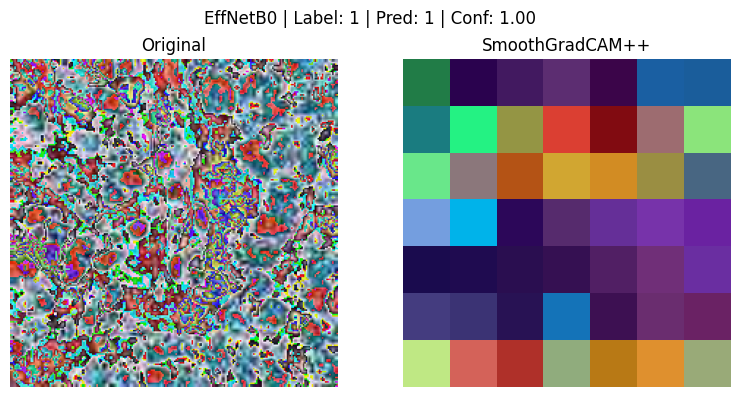

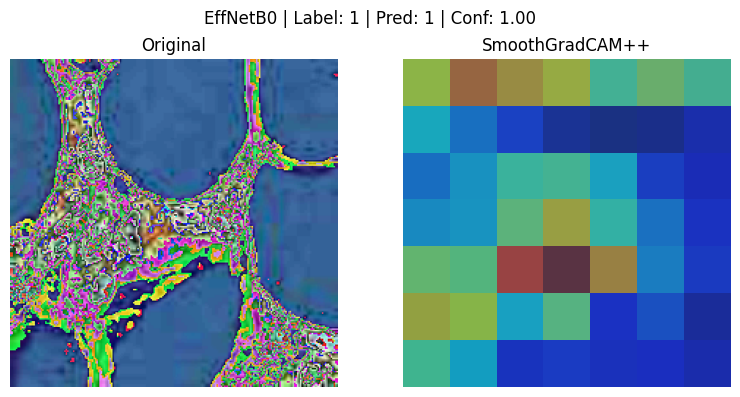

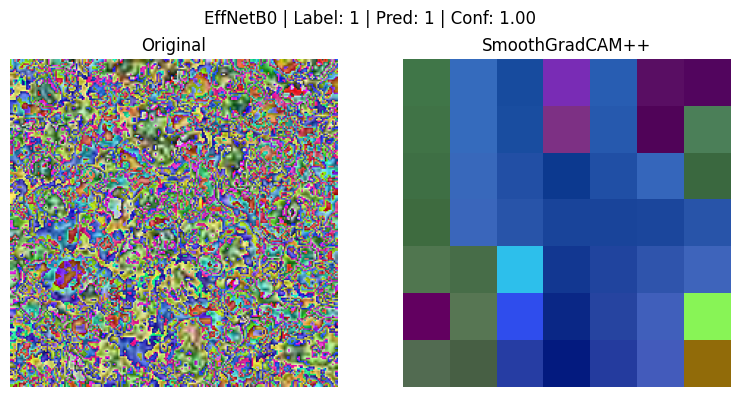

In [ ]:
effnet_path = "/media/lak_05/Windows-SSD/ML/PathoDetect/Final_Models/EfficientNetB0.pth"
effnet_threshold = 0.39
effnet_target_layer = "blocks.6.0.conv_pwl"

with torch.no_grad(), safe_globals([np._core.multiarray.scalar]):
    model_effnet = model_b0().to(device)
    checkpoint = torch.load(effnet_path, map_location=device, weights_only= False)
    model_effnet.load_state_dict(checkpoint["model_state"])
    model_effnet.eval()

random.seed(999)
sample_indices = random.sample(val_indices, 3)

for idx in sample_indices:
    img_tensor, label = full_dataset[idx]
    visualize_effnet_cam(model_effnet, img_tensor, label, effnet_threshold, effnet_target_layer)


In [ ]:
f1 = f1_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
roc = roc_auc_score(all_labels, all_preds)

print("Ensemble Metrics on Validation Set:")
print(f"F1 Score:     {f1:.4f}")
print(f"Precision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"ROC AUC:      {roc:.4f}")


✅ Ensemble Metrics on Validation Set:
F1 Score:     0.9715
Precision:    0.9644
Recall:       0.9786
ROC AUC:      0.9770


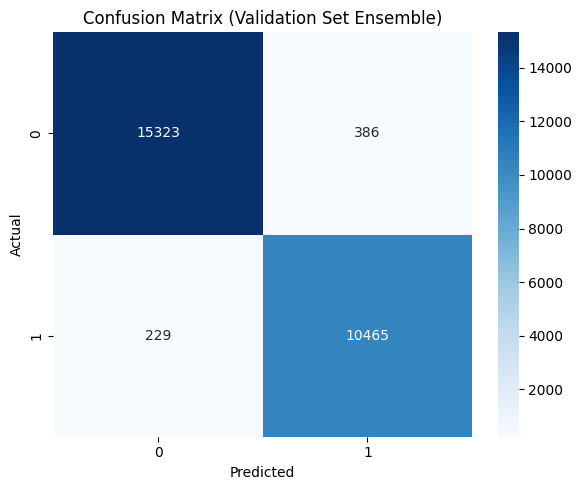

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Validation Set Ensemble)")
plt.tight_layout()
plt.show()


In [ ]:
df = pd.DataFrame({
    "True Label": all_labels,
    "Predicted Label": all_preds,
    "Ensemble Confidence": ensemble_confidences
})
df.to_csv("ensemble_validation_results.csv", index=False)
